### Modèle de prédictions simples pour prédire le taux de résiliation interne chez un courtier partenaire

Tentons de **prédire pour un certain courtier partenaire, le taux de résiliation interne.**

Pour pouvoir appliquer des modèles sur les variables liées aux courtiers, nous devons d'abord agrégé le DataFrame selon le courtier_code_partenaire. 

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_portefeuille= pd.read_csv("s3://kbourbon/projet-bdc-data/alptis/training/apprentissage_portefeuille_2023_11.csv", sep=";" )

/tmp/ipykernel_1748/4002779361.py:6: DtypeWarning: Columns (0: client_nps_date_reponse_n_moins1, 1: client_nps_verbatim_n_moins1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_portefeuille= pd.read_csv("s3://kbourbon/projet-bdc-data/alptis/training/apprentissage_portefeuille_2023_11.csv", sep=";" )


In [6]:
#Création d'une fonction qui crée un dataframe agrégé par type de courtier, à partir de df_portefeuille

def aggregate_courtier(df_portefeuille):
    """  This function merges, aggregates and prepares broker-level data by courtier_code_partenaire
        for future analysis and modelling. 
        Takes the dataframe portefeuille as input and returns
         the aggregated broker relative DataFrame

        One important step consists in transforming the percentage of cancellations
        ("resiliation_pct") into a numerical categorical variable ("resiliation_cat").
        To do this, the function defines four cancellation–intensity bands (bins) and
        assigns each of them a numerical code:

            - 0% to 25%   → category 1 (low cancellation rate)
            - 25% to 50%  → category 2 (medium cancellation rate)
            - 50% to 80%  → category 3 (high cancellation rate)
            - 80% to 100% → category 4 (very high cancellation rate)
        """

    #Compute the internal resiliation rate per broker
    dict_client_courtier= df_portefeuille["courtier_code_partenaire"].value_counts().to_dict()
    dict_resiliation_courtier=df_portefeuille.groupby("courtier_code_partenaire").agg({"target_resiliation_6mois": "sum"}).to_dict()["target_resiliation_6mois"]
    dict_pourc_resiliation_courtier= dict()
    for courtier in dict_client_courtier.keys():
        dict_pourc_resiliation_courtier[courtier]= round(dict_resiliation_courtier[courtier]/dict_client_courtier[courtier]*100,2)
    df_resiliation = pd.DataFrame(list(dict_pourc_resiliation_courtier.items()), columns=["courtier_code_partenaire", "resiliation_pct"])
   
    # Left merge the resiliation rate column with the rest of the portefeuille Df
    df_courtier = df_resiliation.merge(df_portefeuille, on="courtier_code_partenaire", how="left")

    # Définition des bins et valeurs numériques
    bins = [0, 25, 50, 80, 100]
    labels_num = [1, 2, 3, 4]

    df_courtier["courtier_resiliation_cat"] = pd.cut(
        df_courtier["resiliation_pct"],
        bins=bins,
        labels=labels_num,
        include_lowest=True
    ).astype(int)

    # Nombre total de clients par courtier
    df_courtier["courtier_nbre_client"] = df_courtier.groupby("courtier_code_partenaire")["client_code"].transform("count")

    # Colonnes à sommer
    colonnes_sum = [
        "courtier_est_escompte",
        "courtier_nb_affaires_n_moins1",
        "courtier_nb_radiations_n_moins1",
        "courtier_nb_affaires_n_moins2",
        "courtier_nb_radiations_n_moins2"
    ]

    # Colonnes uniques
    colonnes_unique = [
        "courtier_reseau_courtage",
        "courtier_segmentation_interne",
        "courtier_type_commission",
        "courtier_anciennete_annees"
    ]

    # Agrégation principale
    df_agg = df_courtier.groupby("courtier_code_partenaire").agg(
        courtier_resiliation_cat=("courtier_resiliation_cat", "first"),
        courtier_resiliation_pct= ("resiliation_pct", "first"),
        courtier_nbre_client=("courtier_nbre_client", "first"),
        courtier_anciennete_annees=("courtier_anciennete_annees", "first"),
        courtier_segmentation_interne=("courtier_segmentation_interne", "first")
    ).reset_index()

    # Agrégation secondaire : somme
    df_agg_sum = df_courtier.groupby("courtier_code_partenaire")[colonnes_sum].sum().reset_index()

    # Agrégation secondaire : valeurs uniques
    df_agg_unique = df_courtier.groupby("courtier_code_partenaire")[colonnes_unique].first().reset_index()

    # Assemblage final
    df_agg = (
        df_agg
        .merge(df_agg_sum, on="courtier_code_partenaire", how="left")
        .merge(df_agg_unique, on="courtier_code_partenaire", how="left")
    )

    #Drop duplicates
    df_agg=df_agg.drop(columns= ["courtier_segmentation_interne_y", "courtier_anciennete_annees_y"])
    df_agg=df_agg.rename(columns={"courtier_segmentation_interne_x":"courtier_segmentation_interne","courtier_anciennete_annees_x":"courtier_anciennete_annees"})

    #create hot encoder for categorical columns
    #df_agg=pd.get_dummies(df_agg, columns=["courtier_reseau_courtage","courtier_segmentation_interne", "courtier_type_commission"],dtype='int')

    return df_agg

In [7]:
df= aggregate_courtier(df_portefeuille)

We've created a function that merges all broker-related information using the key courtier_code_partenaire.
It also builds a target variable called **courtier_resiliation_cat**, which is a categorical indicator used for classification.
This target represents the internal cancellation rate of each broker over the next six months.

The function merges, aggregates, and prepares the broker-level dataset for further analysis and clustering.
The cancellation rate is split into four categories, which become the target variable for the courtier dataframe:

0% to 25% → category 1 (low cancellation rate)

25% to 50% → category 2 (medium cancellation rate)

50% to 80% → category 3 (high cancellation rate)

80% to 100% → category 4 (very high cancellation rate)

The idea is to use it to estimate each broker’s cancellation risk.
This would later help predict the client-level target and evaluate the “cost of cancellation” for Alptis, depending on the broker’s commission type (courtier_type_commission)

In [4]:
df.columns

Index(['courtier_code_partenaire', 'courtier_resiliation_cat',
       'courtier_resiliation_pct', 'courtier_nbre_client',
       'courtier_anciennete_annees', 'courtier_segmentation_interne',
       'courtier_est_escompte', 'courtier_nb_affaires_n_moins1',
       'courtier_nb_radiations_n_moins1', 'courtier_nb_affaires_n_moins2',
       'courtier_nb_radiations_n_moins2', 'courtier_reseau_courtage',
       'courtier_type_commission'],
      dtype='str')

In [ ]:
#Target: courtier_resiliation_pct or courtier_resiliation_cat
# Features of omportane: courtier_type_commission, courtier_nb_client, 
# courtier_anciennete_annees, courtier_segmentation_interne, courtier_est_escompte

<Axes: >

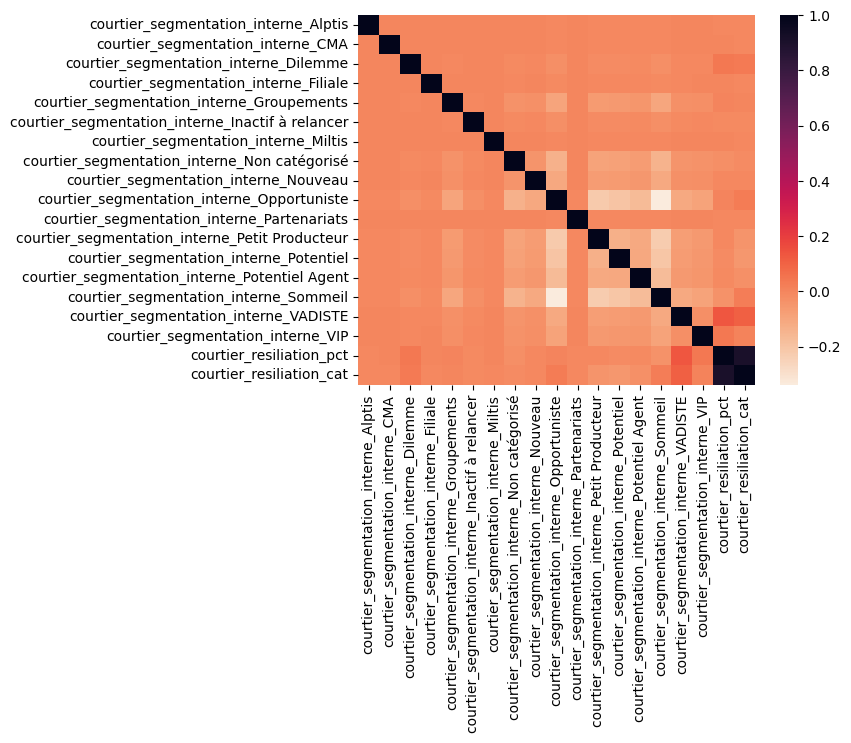

In [5]:
#Correlation between the target and the segmentation typens
df_broker_modified=pd.get_dummies(df, columns=["courtier_reseau_courtage","courtier_segmentation_interne", "courtier_type_commission"],dtype='int')
filtered_columns=[column for column in df_broker_modified.columns if column.startswith("courtier_segmentation_interne")]+["courtier_resiliation_pct", "courtier_resiliation_cat"]
df_broker_filtered= df_broker_modified[filtered_columns]
corr= df_broker_filtered.corr()
sns.heatmap(corr,cmap=sns.cm.rocket_r)

<Axes: >

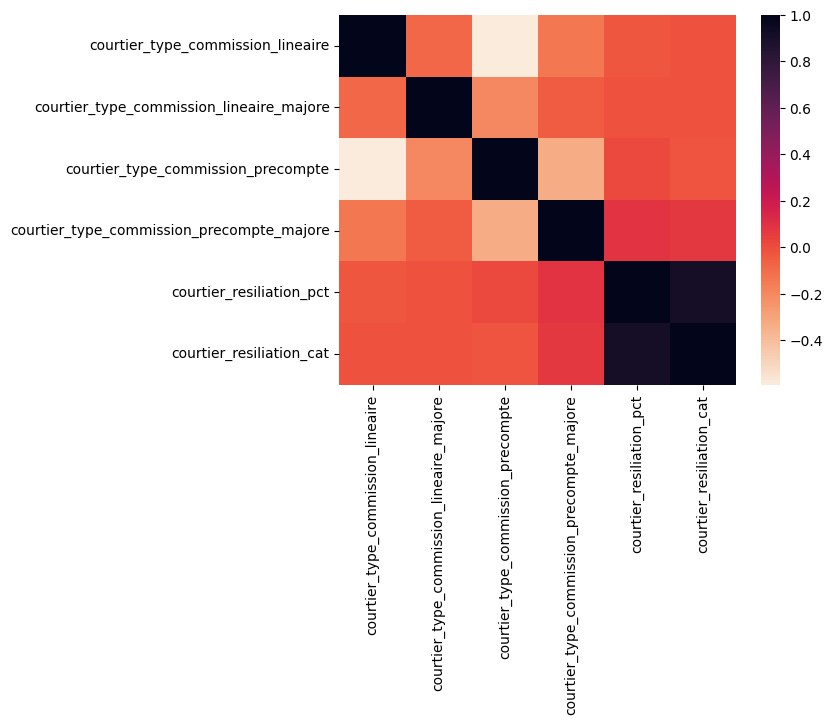

In [6]:
#between the target and the type of commission
filtered_columns=[column for column in df_broker_modified.columns if column.startswith("courtier_type_commission")]+["courtier_resiliation_pct", "courtier_resiliation_cat"]
df_broker_filtered= df_broker_modified[filtered_columns]
corr= df_broker_filtered.corr()
sns.heatmap(corr,cmap=sns.cm.rocket_r)

At first sight, no significant difference concerning the correlation between the internal segmentation and the internal churn rate. But the categories "VADISTE" and "Dilemme" seem to be the most correlated with the targets.
Same for the commission types, with a little bigger correlation for the "precompte majore" type of commission.

### Segmentation on segmentation interne


Let's try to learn on the different categories of internal segmentation ; to do so, let's create a dataframe aggregated by type of segmentation from the dataframe aggregate by courtier_code_partenaire.  
First we have to create dummies on courtier_type_commission and courtier_reseau_courtage (only categorical columns). Then, we just sum all the columns and the column "courtier_code_partenaire" that can get rid of.

In [37]:
df=pd.get_dummies(df, columns=["courtier_type_commission","courtier_reseau_courtage"], dtype=int).drop(columns=["courtier_resiliation_pct","courtier_resiliation_cat"])
df_segm=df.groupby("courtier_segmentation_interne").sum().reset_index()
df_segm["courtier_anciennete_annees"]= df.groupby("courtier_segmentation_interne")['courtier_anciennete_annees'].mean().values
df_segm=df_segm.drop(columns="courtier_code_partenaire")


In [43]:
df_segm["courtier_evolution_nb_affaires"]=df_segm["courtier_nb_affaires_n_moins1"]-df_segm["courtier_nb_affaires_n_moins2"]
df_segm[["courtier_segmentation_interne","courtier_nbre_client","courtier_anciennete_annees","courtier_est_escompte","courtier_evolution_nb_affaires"]]

,courtier_segmentation_interne,courtier_nbre_client,courtier_anciennete_annees,courtier_est_escompte,courtier_evolution_nb_affaires
0,Alptis,10460,23.000000,900,224151
1,CMA,13860,16.000000,401,9249703
2,Dilemme,264,6.666667,190,706
3,Filiale,6326,7.000000,9,324939
4,Groupements,5714,8.325758,2556,-261597
5,Inactif à relancer,465,17.090909,109,160
6,Miltis,2775,11.000000,0,142704
7,Non catégorisé,2176,0.544061,576,2909
8,Nouveau,1754,1.056250,492,12039
9,Opportuniste,8597,10.880696,621,-134


<Axes: xlabel='courtier_evolution_nb_affaires', ylabel='courtier_segmentation_interne'>

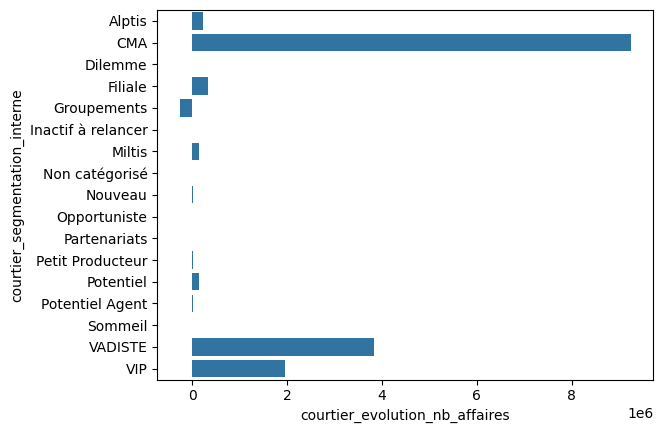

In [51]:
sns.barplot(df_segm, y="courtier_segmentation_interne",x="courtier_evolution_nb_affaires")


Clearly, the evolution between the clients of n-2 and n-1 is the variable that discriminate the most the different categories of brokers. 

Let's segmentate the categories based on this: 
- more than 100 000 new clients bewteen n-1 and n-2: very high volume - Alptis, CMA and VIP
- between 100 000 and 5 000: high volume: 
- between 0 and 5000: moderate volume - 
- less than 0: churn (more clients who left) - Opportuniste, Sommeil and Groupements

In [75]:
very_high_volume=list(df_segm[df_segm["courtier_evolution_nb_affaires"]>100000]["courtier_segmentation_interne"])
high_volume=list(df_segm[df_segm["courtier_evolution_nb_affaires"].between(5000,100000)]["courtier_segmentation_interne"])
moderate_volume=list(df_segm[df_segm["courtier_evolution_nb_affaires"].between(0,5000)]["courtier_segmentation_interne"])
negative_volume =list(df_segm[df_segm["courtier_evolution_nb_affaires"]<0]["courtier_segmentation_interne"])

In [77]:
print("Very high volume", very_high_volume)
print("High volume:", high_volume)
print("Moderate volume:", moderate_volume)
print("Negative volume:", negative_volume)


Very high volume ['Alptis', 'CMA', 'Filiale', 'Miltis', 'Potentiel', 'VADISTE', 'VIP']
High volume: ['Nouveau', 'Petit Producteur', 'Potentiel Agent']
Moderate volume: ['Dilemme', 'Inactif à relancer', 'Non catégorisé', 'Partenariats']
Negative volume: ['Groupements', 'Opportuniste', 'Sommeil']


In [88]:
#Creation of new column based on this segmentation on volume brought

df_segm["courtier_segmentation_evolution_volume"] = np.select(
    [
        df_segm["courtier_segmentation_interne"].isin(very_high_volume),
        df_segm["courtier_segmentation_interne"].isin(high_volume),
        df_segm["courtier_segmentation_interne"].isin(moderate_volume),
        df_segm["courtier_segmentation_interne"].isin(negative_volume),
    ],
    [
        "Very high volume",
        "High volume",
        "Moderate volume",
        "Negative volume",
    ], default="Non renseigné")


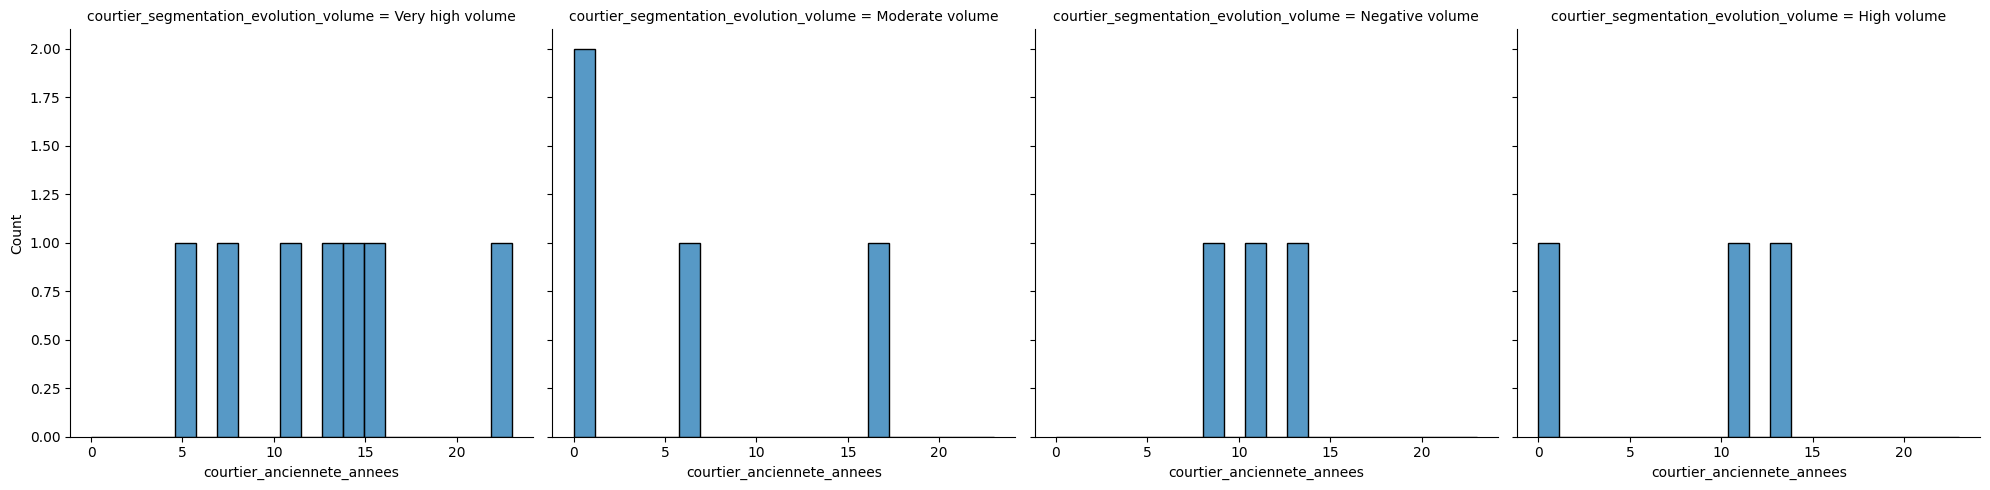

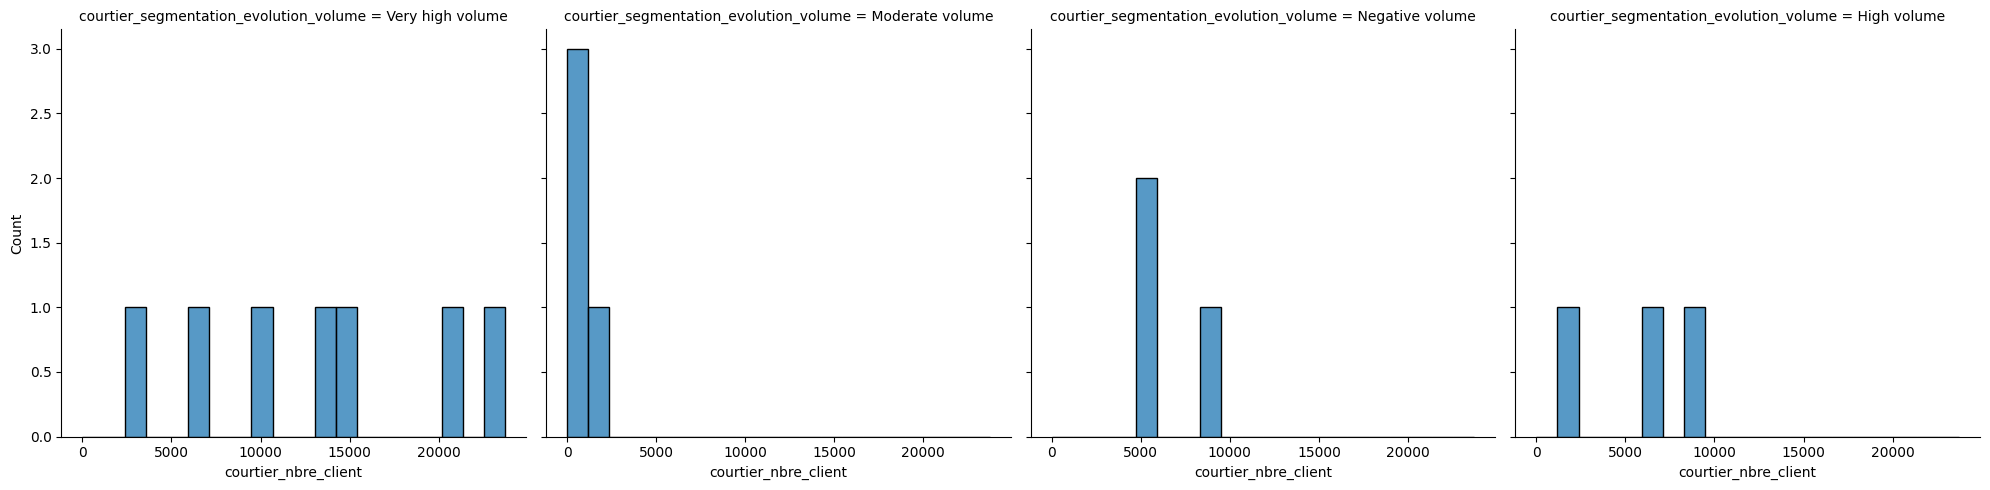

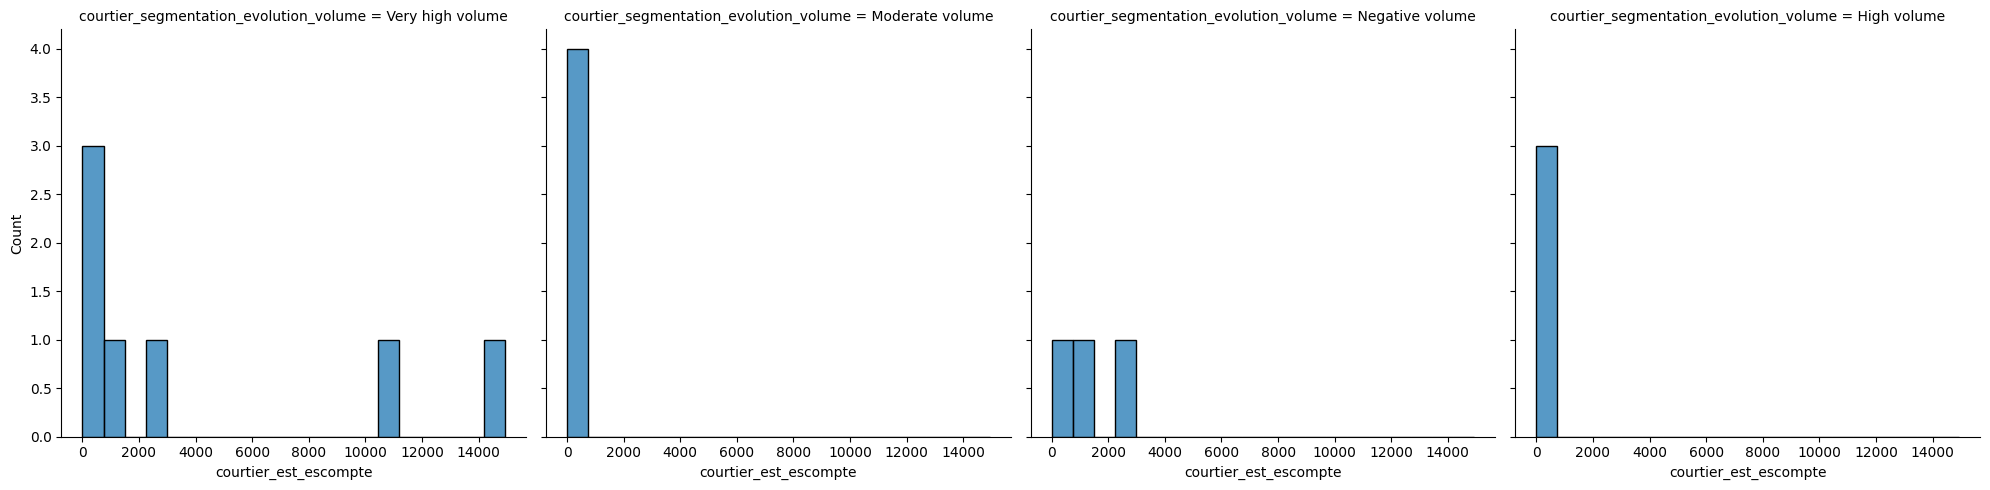

In [109]:
sns.displot(
    data=df_segm,
    x="courtier_anciennete_annees",
    col="courtier_segmentation_evolution_volume",
    kind="hist",
    bins=20,
    common_bins=True
)

sns.displot(
    data=df_segm,
    x="courtier_nbre_client",
    col="courtier_segmentation_evolution_volume",
    kind="hist",
    bins=20,
    common_bins=True
)

sns.displot(
    data=df_segm,
    x="courtier_est_escompte",
    col="courtier_segmentation_evolution_volume",
    kind="hist",
    bins=20,
    common_bins=True
)

We can retrieve some information from the segmentation:
- Very high volume: tend to have more escompte, and clients
- High volume: also a lot of escompte, and clients
- Moderate volume: have less escompte and less clients
- Negative volume: less escompte but more clients

### Segmentation on brokers

Do exactly the same segmentation but on df, the dataframe aggregated by broker :
- Very high volume: >2000
- High volume: 100-2000
- Moderate volume: 0- 100
- Negative volume: <0

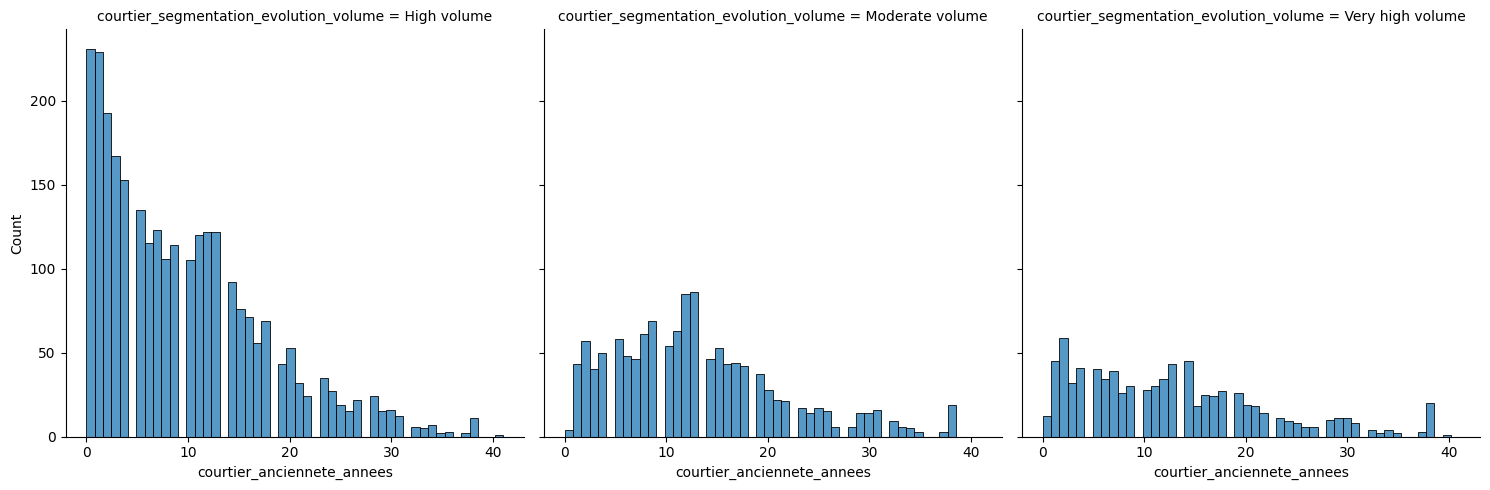

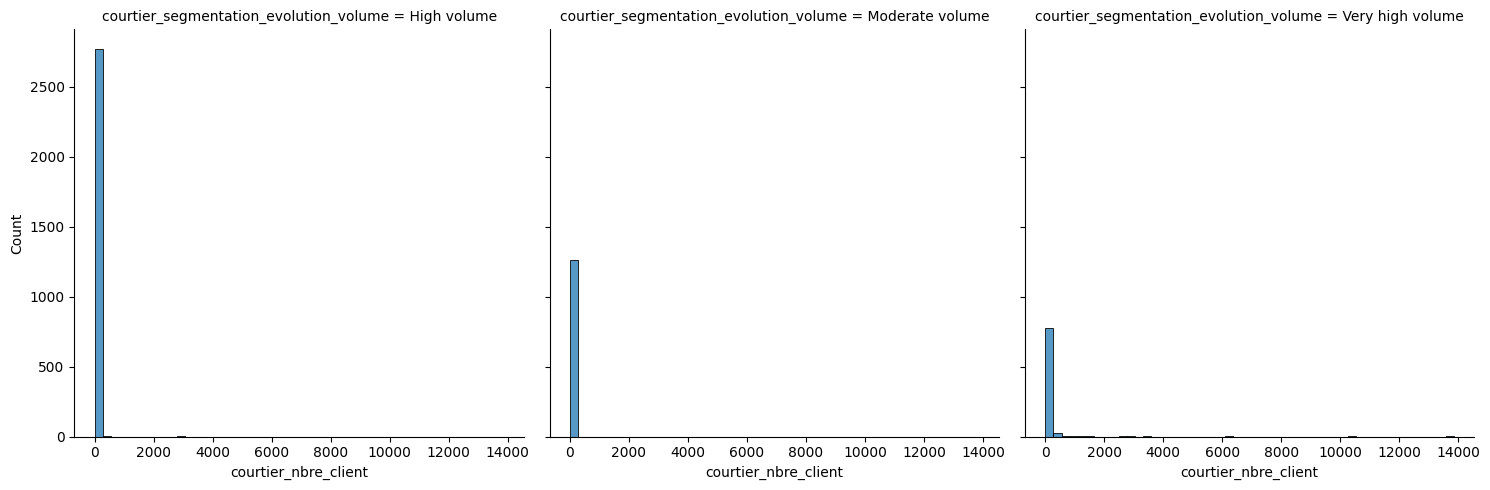

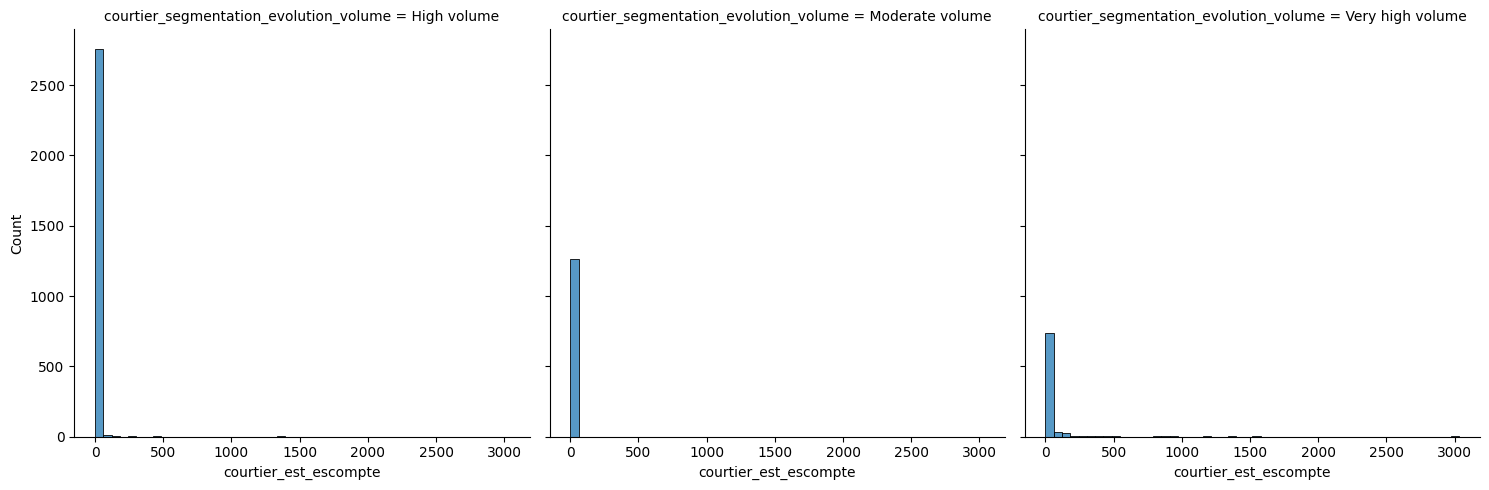

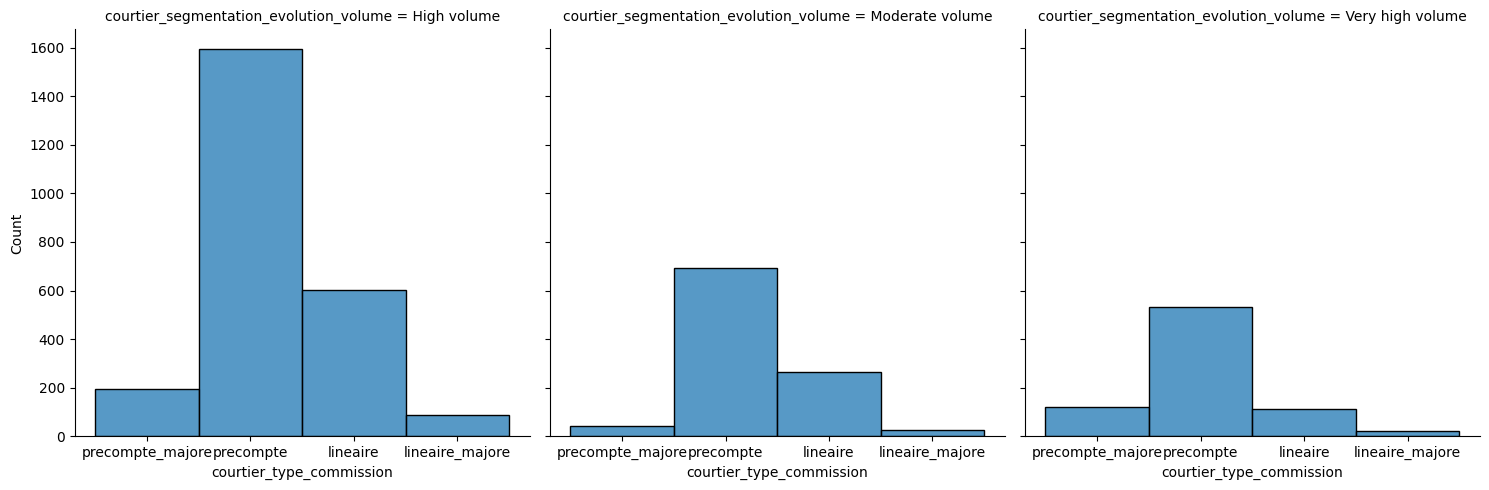

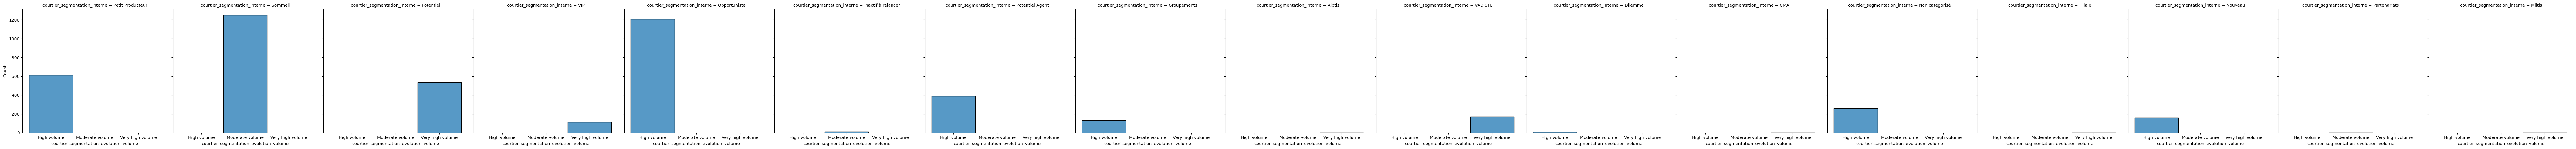

In [40]:
df["courtier_evolution_nb_affaires"]=df["courtier_nb_affaires_n_moins1"]-df["courtier_nb_affaires_n_moins2"]

#Segmentation on volume brought between n-2 and n-1
very_high_volume=list(df[df["courtier_evolution_nb_affaires"]>10000]["courtier_segmentation_interne"])
high_volume=list(df[df["courtier_evolution_nb_affaires"].between(500,10000)]["courtier_segmentation_interne"])
moderate_volume=list(df[df["courtier_evolution_nb_affaires"].between(0,500)]["courtier_segmentation_interne"])
negative_volume =list(df[df["courtier_evolution_nb_affaires"]<0]["courtier_segmentation_interne"])

#Creation of new column based on this segmentation on volume brought
df["courtier_segmentation_evolution_volume"] = np.select(
    [
        df["courtier_segmentation_interne"].isin(very_high_volume),
        df["courtier_segmentation_interne"].isin(high_volume),
        df["courtier_segmentation_interne"].isin(moderate_volume),
        df["courtier_segmentation_interne"].isin(negative_volume),
    ],
    [
        "Very high volume",
        "High volume",
        "Moderate volume",
        "Negative volume",
    ], default="Non renseigné")

#Plot to see values of diff segmentation on courtier_anciennete, escompte and nbre_client
sns.displot(
    data=df,
    x="courtier_anciennete_annees",
    col="courtier_segmentation_evolution_volume",
    kind="hist",
    bins=50,
    common_bins=True
)

sns.displot(
    data=df,
    x="courtier_nbre_client",
    col="courtier_segmentation_evolution_volume",
    kind="hist",
    bins=50,
    common_bins=True
)

sns.displot(
    data=df,
    x="courtier_est_escompte",
    col="courtier_segmentation_evolution_volume",
    kind="hist",
    bins=50,
    common_bins=True
)

sns.displot(
    data=df,
    x="courtier_type_commission",
    col="courtier_segmentation_evolution_volume",
    kind="hist",
    bins=50,
    common_bins=True
)

sns.displot(
    data=df,
    col="courtier_segmentation_interne",
    x="courtier_segmentation_evolution_volume",
    kind="hist",
    bins=50,
    common_bins=True
)

>When we look closely to the brokers, see that in fact no broker has lost more clients than he brought between n-2 and n-1 (It means that the negative_volume category previously was due to an overall diminution of contracts on the given segmentation interne but no real negative volume)

>Real difference based on the segmentation:
- Moderate volume: between 0 and 15 years of ancietness, balanced
- Very high volume: way more recent brokers (around 0-2 years)
- High volume: way more ancient brokers, around 10-15 years + more clients brought by one broker + more escompte for one broker 

>Last plot show that this segmentation actually differenciates perfectly the different categories of courtier_segmentation_interne. So we can do the segmentation of segmentation interne, it is the same.